# Time Series Monitoring of Turbidity

* **Products used:** 
[wq_annual](https://explorer.digitalearth.africa/products/wq_annual), 
[ls5_sr](https://explorer.digitalearth.africa/products/ls5_sr),
[ls7_sr](https://explorer.digitalearth.africa/products/ls7_sr),
[ls8_sr](https://explorer.digitalearth.africa/products/ls8_sr),
[ls9_sr](https://explorer.digitalearth.africa/products/ls9_sr),
[s2_l2a](https://explorer.digitalearth.africa/products/s2_l2a)

## Background
This notebook is part of a collection of water quality (WQ) analysis notebooks that use Earth observation data to assess surface water conditions. 
Combined, these notebooks provide a more holistic view of water quality by enabling analysis across multiple indicators.

This notebook focuses on __total suspended matter/turbidity__.

The [Water Quality Monitoring Service (WQMS) dataset notebook](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks/blob/main/Datasets/Water_Quality.ipynb) introduces the several variables available in the _annual_ water quality product. However, one may want to monitor these variables on shorter time scales, as we do with turbidity in this notebook.

## Description
This notebook shows how to monitor the Total Suspended Matter (TSM), a proxy for the turbidity, on an individual scene basis and aggregate into monthly spatial medians.

1. [Load in annual data](#Load-in-annual-data)
2. [Apply algorithms to individual timesteps](#Apply-algorithms-to-individual-timesteps)
3. [Plot time series](#Plot-time-series)

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

To import the `water_quality` package, please first run `git clone -b develop https://github.com/digitalearthafrica/deafrica_water_quality.git` in the terminal and update the path below to point to it.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from deafrica_tools.plotting import display_map
from deafrica_tools.datahandling import load_ard

import sys

sys.path.append("/home/jovyan/deafrica_water_quality/src")
from water_quality.mapping.algorithms import (
    set_wq_algorithms,
    run_wq_algorithms,
    harmonize_wq_variables,
    normalize_wq_variables
)
from water_quality.mapping.pixel_correction import R_correction

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app="TSM_monitoring")

## Load in annual data
First we load in data from the [wq_annual](https://explorer.digitalearth.africa/products/wq_annual) product to form a yearly baseline. 
The default location is Lake Manyara in northern Tanzania.

In [3]:
query = {
    "product": "wq_annual",
    "x": (35.72, 35.92),
    "y": (-3.90, -3.35),
    "crs": "EPSG:4326",
    "time": ("2020-01-01", "2025-12-31"),
    "output_crs": "EPSG:6933",
    "resolution": (-10, 10),
    "measurements": [
        "tsm",  # Turbidity
        "clear_water",  # Clear water mask
        "water_mask",  # Water presence mask
    ],
}

In [4]:
display_map(x=query["x"], y=query["y"])

In [5]:
ds = dc.load(**query)

## Apply algorithms to individual timesteps
For short-term monitoring we load in the full set of observations available in DE Africa from the Thematic Mapper (TM; Landsat 5 and 7), Operational Land Imager (OLI; Landsat 8 and 9) and Multispectral Imager (MSI; Sentinel-2) sensors.

### Load satellite scenes in time period

In [6]:
# Dictionary to map load_ard bands to those used by water_quality package
measurements = {
    "oli": {
        "blue": "oli02",
        "green": "oli03",
        "red": "oli04",
        "nir": "oli05",
        "swir_1": "oli06",
        "swir_2": "oli07",
        "pixel_quality": "oli_pq",
    },
    "msi": {
        "coastal_aerosol": "msi01",
        "blue": "msi02",
        "green": "msi03",
        "red": "msi04",
        "red_edge_1": "msi05",
        "red_edge_2": "msi06",
        "red_edge_3": "msi07",
        "nir": "msi08",
        "nir_narrow": "msi8a",
        "swir_1": "msi11",
        "swir_2": "msi12",
        "qa": "msi_pq",
    },
    "tm": {
        "blue": "tm01",
        "green": "tm02",
        "red": "tm03",
        "nir": "tm04",
        "swir_1": "tm05",
        "swir_2": "tm07",
        "pixel_quality": "tm_pq",
    },
}

In [7]:
# Map sensors to products
products = {
    "tm": ["ls5_sr", "ls7_sr"],
    "oli": ["ls8_sr", "ls9_sr"],
    "msi": ["s2_l2a"],
}

In [8]:
# Sensor end dates
SENSOR_END_DATES = {
    "tm": "2023-12-31",  # Landsat 7 science imaging was suspended in Jan 2024
    "oli": None,  # Landsat 8/9 (ongoing)
    "msi": None,  # Sentinel-2 (ongoing)
}

We load in the data for 2023-2025 at 480m to process within 20 minutes and within the memory limits of the standard sandbox (16GB memory). We also use dask chunks to delay loading into memory until necessary.

In [9]:
# Dictionary to store each sensor dataset
ds_list = {}

x_range = (35.72, 35.92)
y_range = (-3.90, -3.35)  # Lake Manyara
start_time = "2023-01-01"
end_time = "2025-12-31"

for sensor in products.keys():

    print(f"Loading {sensor} products: {products[sensor]}")

    sensor_end = SENSOR_END_DATES[sensor]
    effective_end = min(end_time, sensor_end) if sensor_end else end_time

    if start_time > effective_end:
        print(f"Skipping {sensor} (no valid time range)")
        continue

    print(f"Loading {sensor}")
    print(f"time: {start_time} → {effective_end}")

    ds_list[sensor] = load_ard(
        dc=dc,
        products=products[sensor],
        x=x_range,
        y=y_range,
        time=(start_time, effective_end),
        output_crs="EPSG:6933",
        resolution=(-480, 480),
        verbose=True,
        dask_chunks={},
        measurements=list(measurements[sensor].keys()),
    ).rename(measurements[sensor])

    # Get the QA band name from measurements dict
    qa_band = measurements[sensor].get("qa") or measurements[sensor].get(
        "pixel_quality"
    )

    # The water_quality package assumes reflectances between 0-10,000
    # We only scale Landsat as Sentinel-2 is already scaled coming out of load_ard
    bands_to_scale = [b for b in ds_list[sensor].data_vars if b != qa_band]
    if sensor in ["tm", "oli"]:
        ds_list[sensor][bands_to_scale] = ds_list[sensor][bands_to_scale] * 10000

    print(f"Finished loading {sensor}\n")

Loading tm products: ['ls5_sr', 'ls7_sr']
Loading tm
time: 2023-01-01 → 2023-12-31
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls5_sr
    ls7_sr
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 52 time steps as a dask array
Finished loading tm

Loading oli products: ['ls8_sr', 'ls9_sr']
Loading oli
time: 2023-01-01 → 2025-12-31
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])


    ls9_sr
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 496 time steps as a dask array
Finished loading oli

Loading msi products: ['s2_l2a']
Loading msi
time: 2023-01-01 → 2025-12-31
Using pixel quality parameters for Sentinel 2
Finding datasets
    s2_l2a


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])


Applying pixel quality/cloud mask
Returning 983 time steps as a dask array
Finished loading msi



/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])


### Apply TSM algorithm
We provide optional functions to calibrate values to in-situ data, the derivation of which is highlighted in the [DE Africa Water Quality User Guide](https://docs.digitalearthafrica.org/en/latest/data_specs/Water_Quality_specs.html). 
The user may wish to modify these functions.

> **Note:** The TSM processing cells below take $\sim$ 20 minutes with a resolution of 480m for 2023-2025 across Lake Manyara on the Sandbox (2 cores, 16 GB memory), which has a surface area of [470 $\textrm{km}^2$](https://en.wikipedia.org/wiki/Lake_Manyara).

In [10]:
def calibrate_tsm(data):
    a = 0
    b = 0.5824
    c = -2.0559
    return a * data**2 + b * data + c

In [11]:
# No suffix for individual time steps
suffix = ""

# Set group of algorithms for TSM
_, ALGORITHMS_TSM = set_wq_algorithms(suffix)

#### Apply preprocessing steps and TSM algorithm

The steps are applied sequentially using functions from the [water_quality package](https://github.com/digitalearthafrica/deafrica_water_quality/tree/main).

We first align the clear water mask from the annual water quality product (where the floating algae index is below a 0.05 threshold) to match the spatiotemporal dimensions of the observations. We then apply an atmospheric dark pixel Rayleigh correction. Finally, we run the TSM algorithms and apply harmonisation, normalisation, and calibration steps.

More details of the steps are available in the [DE Africa Water Quality User Guide](https://docs.digitalearthafrica.org/en/latest/data_specs/Water_Quality_specs.html).

In [12]:
%%time

ds_dict_tsm = {}

for sensor in products.keys():
    print(sensor)

    print("Aligning clear water mask...")
    water_mask_aligned = ds.clear_water.reindex_like(ds_list[sensor], method="nearest")

    print("Applying Rayleigh correction...")
    ds_corrected = R_correction(
        ds_list[sensor], water_mask_aligned, instrument=sensor, drop=True
    )

    print("Applying clear water mask...")
    ds_masked = ds_corrected.where(water_mask_aligned)

    print("Running TSM algorithms...")
    tsm_ds = run_wq_algorithms(
        instrument_data={sensor: ds_masked}, algorithms_group=ALGORITHMS_TSM
    )

    print("Applying harmonisation...")
    tsm_ds = harmonize_wq_variables(tsm_ds)

    print("Applying normalisation...")
    tsm_ds = normalize_wq_variables(tsm_ds)

    print("Applying calibration...")
    for var in tsm_ds.data_vars:
        tsm_ds[var] = calibrate_tsm(tsm_ds[var])

    ds_dict_tsm[sensor] = tsm_ds

    print(f"Finished {sensor}\n")

tm
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Running TSM algorithms...
Applying harmonisation...


/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: overflow encountered in power
  return self.func(*new_argspec)
/opt/v

Applying normalisation...
Applying calibration...
Finished tm

oli
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Running TSM algorithms...
Applying harmonisation...


/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  re

Applying normalisation...
Applying calibration...
Finished oli

msi
Aligning clear water mask...
Applying Rayleigh correction...
Applying clear water mask...
Running TSM algorithms...
Applying harmonisation...
Applying normalisation...
Applying calibration...
Finished msi

CPU times: user 3min, sys: 11.5 s, total: 3min 11s
Wall time: 17min 46s


In [13]:
# Concatenate values across sensors
tsm_ds = xr.concat(ds_dict_tsm.values(), dim="time").sortby("time")

In [14]:
# Stack values across the variables dimension
tsm_da = tsm_ds.to_stacked_array(
    new_dim="tsm_measures",  # New dimension for stacking
    sample_dims=["time", "y", "x"],  # Keep spatial + temporal dims
    variable_dim="tsm_wq_vars",  # Stores the names of the algorithms
    name="tsm",
)

In [15]:
# Take the median across the variables dimension
tsm_final = tsm_da.median(dim="tsm_measures")

In [16]:
# Calculate the monthly mean image
tsm_monthly = tsm_final.resample(time="1M").mean()

In [17]:
# Take the median over area
tsm_month_median = tsm_monthly.median(dim=("x", "y"))

## Plot time series
Next, we plot an interactive time series of the monthly TSM and CHLA. We also overlay the annual results as a step plot for longer-term monitoring.

In [18]:
# Calibrate annual data to field data
ds["tsm"] = calibrate_tsm(ds.tsm)

In [19]:
# Define series for plotting monthly results
x = tsm_month_median.time.values
y = tsm_month_median.values

# Calculate quantile values for TSM
Q = np.array([0, 0.21, 0.79, 1])
quantile_vals = tsm_month_median.quantile(Q, skipna=True).values
q1, q2 = quantile_vals[1], quantile_vals[2]

# Classify points within quantiles in a vectorised way
status = xr.where(y < q1, "Low", xr.where(y < q2, "Normal", "High"))

In [20]:
# Original yearly data
year_x = pd.to_datetime(ds.tsm.time.values).to_period("Y").to_timestamp()
year_y = ds.tsm.median(dim=("x", "y")).values

# Build monthly timeline covering full span
monthly_index = pd.date_range(
    start=year_x[0], end=year_x[-1] + pd.offsets.YearEnd(0), freq="ME"  # Month end
)

# Map each month to its year value
year_series = pd.Series(year_y, index=year_x)

# Forward-fill within each year
year_monthly = year_series.reindex(monthly_index, method="ffill")

# Final arrays
year_x_monthly = year_monthly.index.values
year_y_monthly = year_monthly.values

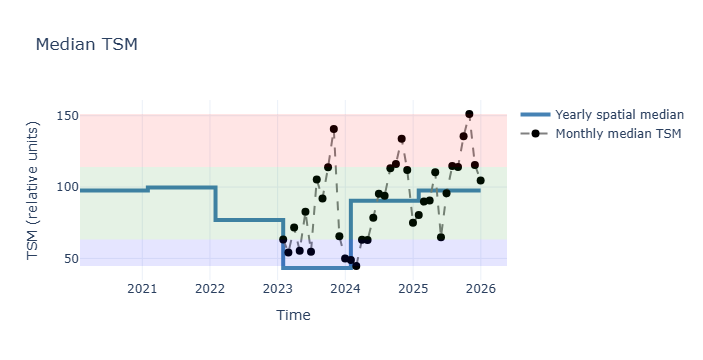

In [21]:
fig = go.Figure()

# Low band
fig.add_hrect(
    y0=quantile_vals[0],
    y1=quantile_vals[1],
    fillcolor="blue",
    opacity=0.1,
    line_width=0,
)

# Normal band
fig.add_hrect(
    y0=quantile_vals[1],
    y1=quantile_vals[2],
    fillcolor="green",
    opacity=0.1,
    line_width=0,
)

# High band
fig.add_hrect(
    y0=quantile_vals[2], y1=quantile_vals[3], fillcolor="red", opacity=0.1, line_width=0
)

# Yearly step line
fig.add_trace(
    go.Scatter(
        x=year_x_monthly,
        y=year_y_monthly,
        mode="lines",
        line_shape="hv",
        line=dict(color="steelblue", width=4, dash="solid"),
        name="Yearly spatial median",
        hovertemplate="<b>Year</b>: %{x|%Y}<br>" "<b>TSM</b>: %{y:.2f}<extra></extra>",
    )
)

# Monthly points
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        name="Monthly median TSM",
        line=dict(color="grey", dash="dash"),
        marker=dict(color="black", size=8),
        customdata=status,
        hovertemplate="<b>Date</b>: %{x}<br>"
        "<b>TSM</b>: %{y:.2f}<br>"
        "<b>Status</b>: %{customdata}<extra></extra>",
    )
)

fig.update_layout(
    title="Median TSM",
    yaxis_title="TSM (relative units)",
    template="plotly_white",
    hovermode="x unified",
    dragmode="zoom",
    xaxis=dict(title="Time", type="date"),
)

fig.show()

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [22]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [23]:
from datetime import datetime

datetime.today().strftime("%Y-%m-%d")

'2026-03-24'